# 07 — PIT feature correlation & redundancy

EDA surface for the **12 frozen PIT features** of `paysim-fraud-recipient-v2`, read from the committed Gold `pre_decision_features` table (the exact strict-PIT vectors training consumes). This is Day 1 of the Sprint 3 validity plan (`docs/reports/sprint-3-feature-model-validity-plan.md`): before touching any model we check the *data → feature* story is sound.

**Questions answered:** How correlated are the 12 features with each other? Is the built-in redundancy real — is `recipient_has_history_Xh` just a binarised `pit_prior_count_Xh`, and are the nested windows `1h ⊂ 24h ⊂ 168h` collinear? Are any features degenerate (near-constant)? Which single feature carries the most fraud signal on its own?

**Two correlations, on purpose.** Amounts and counts are heavy-tailed, so **Pearson** (linear) understates monotone-but-nonlinear ties; **Spearman** (rank) is the honest read for these columns. We show both and compare — large Pearson↔Spearman gaps are themselves a finding.

This notebook is **review-only / output-free** in git (AGENTS §13): it calls into `src/`, runs read-only, changes no contract, trains no model, and must be cleared before commit. It never substitutes the synthetic temporal fixture — it reads the real committed Gold table.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from pit_fintech.config import get_settings
from pit_fintech.data.paysim import resolve_project_root
from pit_fintech.features.paysim_specs import (
    PAYSIM_MODEL_FEATURE_ORDER,
    PAYSIM_STATIC_FEATURE_NAMES,
)

FEATURE_ORDER = list(PAYSIM_MODEL_FEATURE_ORDER)
HISTORY_FEATURES = [f for f in FEATURE_ORDER if f not in PAYSIM_STATIC_FEATURE_NAMES]

PROJECT_ROOT = resolve_project_root(Path.cwd())
settings = get_settings()
data_root = settings.data_root
if not data_root.is_absolute():
    data_root = PROJECT_ROOT / data_root
artifact_root = settings.artifact_root
if not artifact_root.is_absolute():
    artifact_root = PROJECT_ROOT / artifact_root

# Discover the committed Gold pre_decision_features table without hardcoding the snapshot hash.
# Path shape: {data_root}/lakehouse/paysim1/{snapshot_prefix}/gold/pre_decision_features
gold_base = data_root / "lakehouse" / "paysim1"
gold_candidates = (
    sorted(gold_base.glob("*/gold/pre_decision_features")) if gold_base.exists() else []
)
GOLD_PRE_PATH = next((p for p in gold_candidates if (p / "_delta_log").exists()), None)
GOLD_AVAILABLE = GOLD_PRE_PATH is not None

print({"features": len(FEATURE_ORDER), "static": list(PAYSIM_STATIC_FEATURE_NAMES)})
if GOLD_AVAILABLE:
    print({"snapshot_prefix": GOLD_PRE_PATH.parent.parent.name, "gold_pre": str(GOLD_PRE_PATH)})
else:
    display(
        Markdown(
            "> **No committed Gold `pre_decision_features` found.** Build and promote Gold first "
            "(`.\\make.ps1 build-lakehouse -Dataset paysim` then the Gold build/promote flow), "
            "then reload this notebook."
        )
    )

{'features': 12, 'static': ['current_amount', 'event_step', 'transaction_type_transfer']}
{'snapshot_prefix': '16910f90577b0d98', 'gold_pre': 'C:\\workspace\\pit-fintech\\data\\lakehouse\\paysim1\\16910f90577b0d98\\gold\\pre_decision_features'}


In [2]:
# Optional: attach fraud labels so we can measure single-feature signal against the target.
# Labels live in the Silver `paysim_labels` table, resolved from the lakehouse manifest exactly
# as notebook 06 resolves table paths.
LABELS_PATH = None
try:
    from pit_fintech.data.paysim_lakehouse import (
        ApplicationLakehouseManifest,
        _resolve_manifest_path,
        find_latest_paysim_lakehouse_manifest,
    )

    manifest_path = find_latest_paysim_lakehouse_manifest(artifact_root)
    if manifest_path is not None:
        manifest = ApplicationLakehouseManifest.model_validate_json(
            manifest_path.read_text(encoding="utf-8")
        )
        for snap in manifest.tables:
            if snap.table == "paysim_labels":
                LABELS_PATH = _resolve_manifest_path(snap.path, PROJECT_ROOT)
                break
except Exception as exc:  # labels are optional EDA context, never a gate
    print(f"label resolution skipped: {exc}")

LABELS_AVAILABLE = LABELS_PATH is not None and (LABELS_PATH / "_delta_log").exists()
print(
    {
        "labels_available": LABELS_AVAILABLE,
        "labels_path": str(LABELS_PATH) if LABELS_PATH else None,
    }
)

{'labels_available': True, 'labels_path': 'C:\\workspace\\pit-fintech\\data\\lakehouse\\paysim1\\16910f90577b0d98\\silver\\paysim_labels'}


## 1 · Execution control

Loading the full committed Gold table (~2.77M pre-decision rows) is deliberately **opt-in** so `pit notebooks verify` stays fast and this notebook stays output-free. Set `RUN_ANALYSIS = True` interactively to pull the data and compute the correlations below.

`SAMPLE_ROWS` draws a deterministic reservoir sample for a quick first look; set it to `None` for the exact full-population correlations.

In [7]:
RUN_ANALYSIS = True
SAMPLE_ROWS: int | None = 300_000  # None = full population (exact); an int = deterministic sample

frame: pd.DataFrame | None = None
if RUN_ANALYSIS and GOLD_AVAILABLE:
    import duckdb
    from deltalake import DeltaTable

    gold_table = DeltaTable(str(GOLD_PRE_PATH)).to_pyarrow_table()
    connection = duckdb.connect()
    connection.register("gold", gold_table)
    select_cols = ", ".join(f"g.{name}" for name in FEATURE_ORDER)
    sample_clause = (
        f"USING SAMPLE reservoir({int(SAMPLE_ROWS)} ROWS) REPEATABLE (42)"
        if SAMPLE_ROWS is not None
        else ""
    )
    if LABELS_AVAILABLE:
        labels_table = (
            DeltaTable(str(LABELS_PATH)).to_pyarrow_table().select(["source_row_number", "isFraud"])
        )
        connection.register("labels", labels_table)
        frame = connection.execute(
            f"SELECT {select_cols}, l.isFraud AS isFraud "
            f"FROM gold AS g INNER JOIN labels AS l USING (source_row_number) {sample_clause}"
        ).df()
    else:
        frame = connection.execute(f"SELECT {select_cols} FROM gold AS g {sample_clause}").df()
    connection.close()

    # has_history flags arrive as bool/int; cast the whole feature block to float for correlation.
    frame[FEATURE_ORDER] = frame[FEATURE_ORDER].astype("float64")
    print(
        f"rows={len(frame):,}  features={len(FEATURE_ORDER)}  "
        f"labels={'yes' if 'isFraud' in frame.columns else 'no'}  "
        f"mode={'sample' if SAMPLE_ROWS is not None else 'full-population'}"
    )
else:
    display(
        Markdown(
            "Analysis skipped. Set `RUN_ANALYSIS = True` (and ensure Gold is built) "
            "to run the cells below."
        )
    )

rows=300,000  features=12  labels=yes  mode=sample


In [8]:
def show_heatmap(corr: pd.DataFrame, title: str) -> None:
    """Render a correlation matrix as a heatmap; fall back to a numeric table without matplotlib."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print(
            f"[{title}] matplotlib not installed; showing the numeric matrix instead. "
            "Run `.\\make.ps1 setup` (or `uv sync`) to enable heatmaps."
        )
        display(corr.round(2))
        return
    values = corr.values
    fig, ax = plt.subplots(figsize=(9.5, 8.5))
    image = ax.imshow(values, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(len(corr.columns)), labels=list(corr.columns), rotation=90, fontsize=8)
    ax.set_yticks(range(len(corr.index)), labels=list(corr.index), fontsize=8)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(
                j,
                i,
                f"{values[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if abs(values[i, j]) > 0.6 else "black",
            )
    ax.set_title(title)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

## 2 · Pearson heatmap (linear correlation)

Standard linear correlation across all 12 features. Reads the *linear* dependence — the block structure to look for: the three `has_history` flags against their matching `count`, and the amount/count columns across the nested windows.

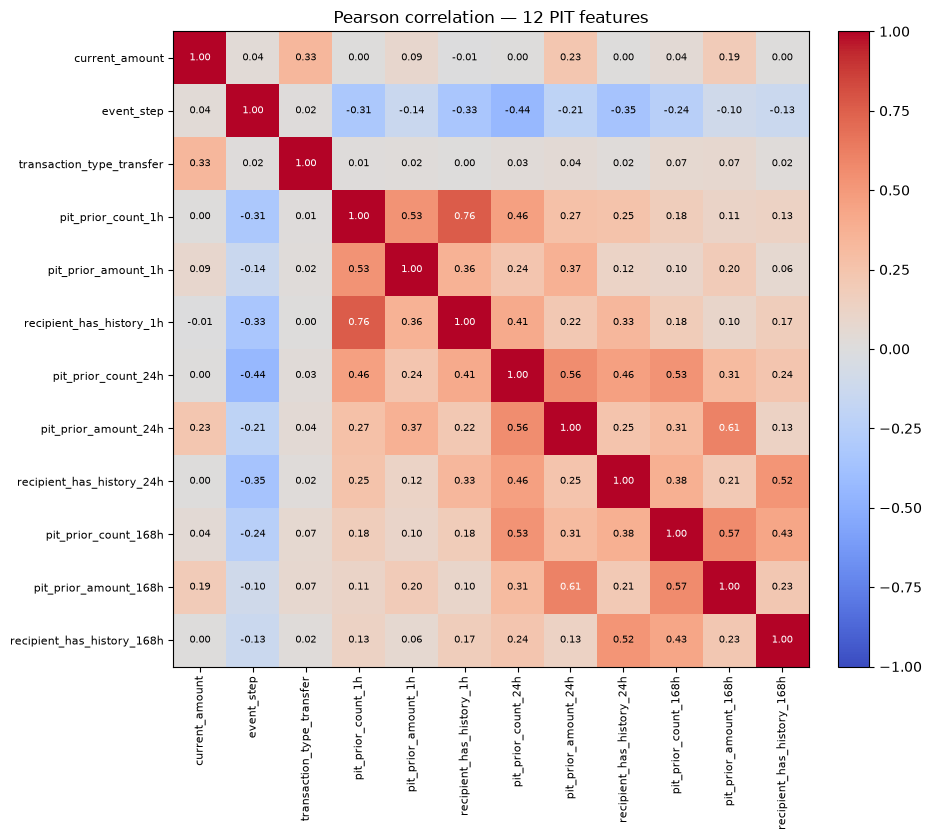

In [9]:
if frame is not None:
    pearson = frame[FEATURE_ORDER].corr(method="pearson")
    show_heatmap(pearson, "Pearson correlation — 12 PIT features")
else:
    print("Skipped: enable RUN_ANALYSIS above.")

## 3 · Spearman heatmap (rank correlation)

The honest read for heavy-tailed `amount`/`count` columns. Where Spearman is markedly higher than Pearson, the relationship is monotone but nonlinear — a tree model captures it, a linear model largely misses it (this is exactly why the ladder later includes both).

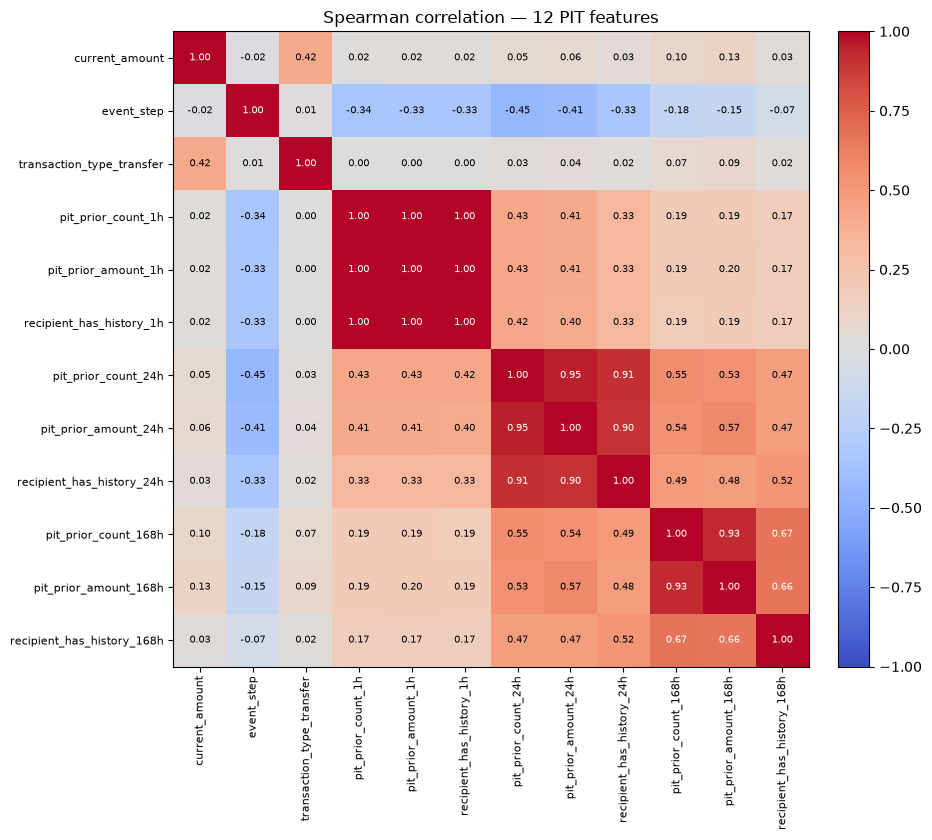

In [10]:
if frame is not None:
    spearman = frame[FEATURE_ORDER].corr(method="spearman")
    show_heatmap(spearman, "Spearman correlation — 12 PIT features")
else:
    print("Skipped: enable RUN_ANALYSIS above.")

## 4 · Built-in redundancy (the design hypothesis)

The plan predicts two structural redundancies. Here we test them on named pairs instead of eyeballing the grid:

- **`has_history` vs `count`** in the same window — `recipient_has_history_Xh` is `pit_prior_count_Xh > 0`, so it should be near-collinear (Spearman close to 1).
- **Nested windows** — `1h ⊂ 24h ⊂ 168h`, so `count`/`amount` should correlate strongly across adjacent windows.

Pairs with `|corr| > 0.9` are flagged as **strongly redundant** — candidates the Day-3 ablation will try to drop.

In [11]:
REDUNDANCY_PAIRS = [
    ("pit_prior_count_1h", "recipient_has_history_1h"),
    ("pit_prior_count_24h", "recipient_has_history_24h"),
    ("pit_prior_count_168h", "recipient_has_history_168h"),
    ("pit_prior_count_1h", "pit_prior_count_24h"),
    ("pit_prior_count_24h", "pit_prior_count_168h"),
    ("pit_prior_amount_1h", "pit_prior_amount_24h"),
    ("pit_prior_amount_24h", "pit_prior_amount_168h"),
    ("pit_prior_count_168h", "pit_prior_amount_168h"),
]

if frame is not None:
    rows = []
    for left, right in REDUNDANCY_PAIRS:
        pearson_r = frame[left].corr(frame[right], method="pearson")
        spearman_r = frame[left].corr(frame[right], method="spearman")
        rows.append(
            {
                "feature_a": left,
                "feature_b": right,
                "pearson": round(pearson_r, 3),
                "spearman": round(spearman_r, 3),
                "strongly_redundant": bool(abs(spearman_r) > 0.9),
            }
        )
    display(pd.DataFrame(rows))
else:
    print("Skipped: enable RUN_ANALYSIS above.")

,feature_a,feature_b,pearson,spearman,strongly_redundant
0,pit_prior_count_1h,recipient_has_history_1h,0.761,0.998,True
1,pit_prior_count_24h,recipient_has_history_24h,0.464,0.909,True
2,pit_prior_count_168h,recipient_has_history_168h,0.430,0.665,False
3,pit_prior_count_1h,pit_prior_count_24h,0.464,0.428,False
4,pit_prior_count_24h,pit_prior_count_168h,0.525,0.550,False
5,pit_prior_amount_1h,pit_prior_amount_24h,0.374,0.411,False
6,pit_prior_amount_24h,pit_prior_amount_168h,0.607,0.575,False
7,pit_prior_count_168h,pit_prior_amount_168h,0.566,0.927,True


## 5 · Distribution & degeneracy check

A feature with near-zero variance carries no signal regardless of correlation. Heavy skew (typical of `amount`/`count`) explains Pearson↔Spearman gaps and motivates rank-based reads. `nunique` on the `has_history` flags should be 2 (binary).

In [12]:
if frame is not None:
    profile = frame[FEATURE_ORDER].agg(["mean", "std", "min", "max", "nunique"]).T
    profile["skew"] = frame[FEATURE_ORDER].skew()
    profile["near_constant"] = profile["std"] < 1e-9
    display(profile.round(3))
else:
    print("Skipped: enable RUN_ANALYSIS above.")

,mean,std,min,max,nunique,skew,near_constant
current_amount,317923.379,883944.758,0.0,7.382349e+07,298624.0,22.418,False
event_step,242.160,141.946,1.0,7.430000e+02,656.0,0.375,False
transaction_type_transfer,0.191,0.393,0.0,1.000000e+00,2.0,1.572,False
pit_prior_count_1h,0.182,0.640,0.0,3.200000e+01,20.0,7.285,False
pit_prior_amount_1h,53149.855,391096.512,0.0,7.050845e+07,35813.0,57.058,False
recipient_has_history_1h,0.123,0.328,0.0,1.000000e+00,2.0,2.300,False
pit_prior_count_24h,1.611,3.095,0.0,8.200000e+01,73.0,5.295,False
pit_prior_amount_24h,463606.297,1659734.062,0.0,1.856143e+08,165483.0,29.569,False
recipient_has_history_24h,0.558,0.497,0.0,1.000000e+00,2.0,-0.233,False
pit_prior_count_168h,5.357,5.779,0.0,9.700000e+01,87.0,2.222,False


## 6 · Single-feature signal vs the fraud target

Correlation between features says nothing about *usefulness*. Here each feature is scored on its own against `isFraud` with ROC-AUC (imbalance-robust, direction-agnostic via `abs_lift = |auc - 0.5|`) plus per-class means. This ranks which of the 12 hand-written PIT features actually separate fraud — the correlation grid says which ones are redundant, this says which ones are worth keeping. Requires labels + scikit-learn.

In [13]:
if frame is not None and "isFraud" in frame.columns:
    from sklearn.metrics import roc_auc_score

    target = frame["isFraud"].astype("int64").to_numpy()
    rows = []
    for name in FEATURE_ORDER:
        column = frame[name].to_numpy()
        auc = roc_auc_score(target, column)
        rows.append(
            {
                "feature": name,
                "single_feature_auc": round(float(auc), 4),
                "abs_lift": round(abs(float(auc) - 0.5), 4),
                "mean_fraud": round(float(column[target == 1].mean()), 4),
                "mean_legit": round(float(column[target == 0].mean()), 4),
            }
        )
    ranked = pd.DataFrame(rows).sort_values("abs_lift", ascending=False).reset_index(drop=True)
    display(ranked)
elif frame is not None:
    print("Labels unavailable; single-feature signal ranking skipped.")
else:
    print("Skipped: enable RUN_ANALYSIS above.")

,feature,single_feature_auc,abs_lift,mean_fraud,mean_legit
0,pit_prior_amount_168h,0.2046,0.2954,3.596825e+05,1.472325e+06
1,pit_prior_count_168h,0.2060,0.2940,1.332300e+00,5.369700e+00
2,recipient_has_history_168h,0.2396,0.2604,3.034000e-01,8.242000e-01
3,pit_prior_amount_24h,0.2756,0.2244,5.270435e+04,4.648923e+05
4,pit_prior_count_24h,0.2772,0.2228,2.521000e-01,1.615600e+00
5,recipient_has_history_24h,0.2824,0.2176,1.239000e-01,5.591000e-01
6,current_amount,0.6865,0.1865,1.556289e+06,3.140476e+05
7,event_step,0.6676,0.1676,3.663878e+02,2.417715e+02
8,transaction_type_transfer,0.6496,0.1496,4.893000e-01,1.901000e-01
9,pit_prior_amount_1h,0.4420,0.0580,1.090668e+03,5.331279e+04


## What this notebook produces

Day-1 validity read of the *data → feature* layer, feeding the Day-3 ablation:

- **Correlation structure** of the 12 PIT features (Pearson + Spearman), with Pearson↔Spearman gaps flagged as nonlinear-but-monotone signal.
- **Redundancy verdict** on the named pairs — which `has_history`/`count` and nested-window pairs are `|corr| > 0.9` (strongly redundant, ablation candidates).
- **Degeneracy check** — any near-constant feature.
- **Single-feature signal ranking** vs the fraud target (when labels are available).

No feature is dropped here — dropping a stored feature is a contract bump (FeatureSpec v3 + ADR + Gold backfill), explicitly out of scope this week. This notebook only tells the ablation *where to look*.